# Section 2: The Agent Loop

*Duration: 20 minutes*

---

Section 1 established that a passive RAG pipeline has no recovery path when retrieval fails. It retrieves, it answers, it moves on. The architecture has no place to inspect, evaluate, or choose a different strategy.

This section builds the control structure that fixes that: the **agent loop**.

The idea is simple. Instead of executing a fixed sequence (retrieve then answer), the model gets a decision to make at each step. It can retrieve, evaluate what came back, rewrite the query and try again, or decide that it cannot answer. The retriever does not go away. It becomes one tool among several, and the model decides when and how to use it.

By the end of this section, the same model and the same retriever will correctly answer questions that the passive pipeline got wrong. Nothing about the model or the data changes. Only the control structure changes.

## 2.1 Setup and Recap

We need the same components from Section 1: the evaluation results, the MaaS endpoint, and a retriever over the corpus. The cells below load each one.

In [59]:
import json
import os
from openai import OpenAI

# Load evaluation results from Section 1
EVAL_PATH = "../prebuilt/eval_results.json"

with open(EVAL_PATH, "r", encoding="utf-8") as f:
    eval_data = json.load(f)

results = eval_data["results"]
failures = [r for r in results if r["classification"] != "pass"]

print(f"Loaded {len(results)} questions, {len(failures)} failures")
print(f"\nFailing questions:")
for f_ in failures:
    print(f"  {f_['id']}: {f_['question']}")

Loaded 10 questions, 2 failures

Failing questions:
  q02: Why can't Elves roll higher than a d6 for hit points?
  q03: Can a character wear leather armor and cast spells?


### 2.1.1 Load Configuration

The cell below adds the project root to the Python path and imports the shared `config` module, which provides the API key, endpoint URL, and model ID. It then creates an OpenAI client pointed at the MaaS-hosted Granite model, the same endpoint used in Section 1.

In [60]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import config
from openai import OpenAI

client = OpenAI(api_key=config.API_KEY, base_url=config.ENDPOINT_BASE)

print("✅ Connection Successful")
print("  Details")
print(f"\t- Connected to : {config.ENDPOINT_BASE}")
print(f"\t- API Key: {config.API_KEY[:8]}...")
print(f"\t- Model        : {config.MODEL_ID}")

✅ Connection Successful
  Details
	- Connected to : https://litellm-prod.apps.maas.redhatworkshops.io/v1
	- API Key: sk-hyOdW...
	- Model        : granite-3-2-8b-instruct


### 2.1.2 Load the Retriever

The cell below loads a lightweight TF-IDF retriever from `utils/retriever.py`. It replaces the ChromaDB vector store used in the Escalation Lab with a pure-Python implementation that has no external dependencies.

Under the hood, the retriever loads 30 pre-chunked passages from the Basic Fantasy RPG rulebook (`prebuilt/bfrpg_chunks.json`), builds a TF-IDF index over them, and ranks chunks by cosine similarity against incoming queries. It exposes the same `.query()` interface that ChromaDB provides, accepting a query string and returning the top-n matching document chunks with distance scores, so the agent loop code that follows does not need to know which retrieval engine is behind it.

The trade-off is precision: TF-IDF matches on keyword overlap rather than semantic meaning, so some queries will retrieve topically adjacent but not directly relevant chunks. That is fine for this lab. In fact, it makes the retrieval evaluator (Section 2.2) more important: the agent needs to judge whether what came back is actually useful before answering.

In [61]:
from utils.retriever import Retriever

collection = Retriever.load()

print(f"Collection    : {collection.name}")
print(f"Documents     : {collection.count()}")

Collection    : basic_fantasy_corpus
Documents     : 30


## 2.2 The Retrieval Evaluator

The first thing the passive pipeline lacks is the ability to judge its own retrieval. It pulls chunks and feeds them to the model without asking: *are these chunks actually useful for this question?*

The fix is a **retrieval evaluator**: a prompt that takes the question and the retrieved chunks and returns a judgment. Not an answer. Just a judgment: are these chunks sufficient?

This is the simplest possible agent capability. The model already knows how to do this. The passive pipeline just never asked.

In [62]:
EVALUATOR_PROMPT = """You are a retrieval quality evaluator for a rules-reference system.

You will receive a QUESTION and a set of RETRIEVED CHUNKS from a document corpus.

Your job is to judge whether the retrieved chunks contain enough information to
correctly and completely answer the question.

Respond with EXACTLY one of these JSON objects (no other text):

If the chunks contain the answer:
{"verdict": "sufficient", "reason": "<one sentence>"}

If the chunks are related but incomplete:
{"verdict": "partial", "reason": "<one sentence>", "missing": "<what is missing>"}

If the chunks are not relevant to the question:
{"verdict": "irrelevant", "reason": "<one sentence>"}
"""


def evaluate_retrieval(question, chunks, model_client, model_id):
    """Ask the model to judge whether retrieved chunks can answer the question."""
    chunk_text = "\n\n---\n\n".join(chunks)

    response = model_client.chat.completions.create(
        model=model_id,
        messages=[
            {"role": "system", "content": EVALUATOR_PROMPT},
            {"role": "user", "content": f"QUESTION:\n{question}\n\nRETRIEVED CHUNKS:\n{chunk_text}"}
        ],
        temperature=0.0
    )

    raw = response.choices[0].message.content.strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"verdict": "error", "reason": "Could not parse evaluator response", "raw": raw}


print("Evaluator defined.")

Evaluator defined.


Test the evaluator on one passing and one failing question. The evaluator should confirm that chunks are sufficient for the passing question and flag a problem for the failing one.

In [63]:
passes = [r for r in results if r["classification"] == "pass"]

# Test on a passing question
pass_q = passes[0]
pass_retrieval = collection.query(
    query_texts=[pass_q["question"]], n_results=3, include=["documents"]
)
pass_eval = evaluate_retrieval(
    pass_q["question"], pass_retrieval["documents"][0], client, config.MODEL_ID
)

print("PASSING QUESTION")
print(f"  Q: {pass_q['question']}")
print(f"  Evaluator verdict: {json.dumps(pass_eval, indent=2)}")

# Test on a failing question
fail_q = failures[0]
fail_retrieval = collection.query(
    query_texts=[fail_q["question"]], n_results=3, include=["documents"]
)
fail_eval = evaluate_retrieval(
    fail_q["question"], fail_retrieval["documents"][0], client, config.MODEL_ID
)

print("\nFAILING QUESTION")
print(f"  Q: {fail_q['question']}")
print(f"  Evaluator verdict: {json.dumps(fail_eval, indent=2)}")

PASSING QUESTION
  Q: What happens if a Thief fails an Open Locks attempt?
  Evaluator verdict: {
  "verdict": "sufficient",
  "reason": "The retrieved chunks explain that if a Thief fails an Open Locks attempt, they cannot try that particular lock again until gaining at least one additional level of experience."
}

FAILING QUESTION
  Q: Why can't Elves roll higher than a d6 for hit points?
  Evaluator verdict: {
  "verdict": "sufficient",
  "reason": "The chunks explain that Elves are a combination class incorporating Fighter and Magic-User abilities, and as such, they use the smaller hit die of the two component classes, which is a d6, the same as Magic-Users."
}


The same model that produced the wrong answer in the passive pipeline can *detect* that the retrieval was insufficient. It always could. The passive architecture simply never asked.

This is the core insight behind agentic RAG: the model is not the bottleneck. The control structure is.

## 2.3 Query Rewriting

When the evaluator flags a retrieval as `partial` or `irrelevant`, the agent needs a recovery action. The simplest one: rewrite the query and try again.

The original question is written in natural language by a user. The vector store responds best to queries that match the terminology and phrasing used in the source documents. A rewritten query bridges that gap.

This is not prompt engineering. It is the agent choosing to reformulate its search before committing to an answer.

In [64]:
REWRITER_PROMPT = """You are a search query rewriter for a tabletop RPG rules corpus.

The original query did not retrieve useful results. Your job is to rewrite it so
that a vector similarity search is more likely to find the relevant rules text.

Strategies:
- Use terminology that would appear in a rulebook (e.g., "hit die" instead of
  "hit points dice", "ability score modifier" instead of "bonus")
- If the question asks about a specific class, level, or stat, include those
  terms explicitly
- If the question asks about a table or chart, reference the table name
- Break compound questions into the most specific sub-question

You will also receive the REASON the previous retrieval was judged insufficient.
Use that information to guide your rewrite.

Respond with EXACTLY one JSON object (no other text):
{"rewritten_query": "<your rewritten query>", "strategy": "<one sentence explaining what you changed>"}
"""


def rewrite_query(question, eval_result, model_client, model_id):
    """Rewrite a query based on the evaluator's feedback."""
    reason = eval_result.get("reason", "Retrieval was insufficient.")
    missing = eval_result.get("missing", "")

    context = f"ORIGINAL QUERY:\n{question}\n\nREASON RETRIEVAL FAILED:\n{reason}"
    if missing:
        context += f"\nMISSING INFORMATION:\n{missing}"

    response = model_client.chat.completions.create(
        model=model_id,
        messages=[
            {"role": "system", "content": REWRITER_PROMPT},
            {"role": "user", "content": context}
        ],
        temperature=0.0
    )

    raw = response.choices[0].message.content.strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"rewritten_query": question, "strategy": "parse_error", "raw": raw}


print("Query rewriter defined.")

Query rewriter defined.


In [65]:
# Demonstrate query rewriting on a failing question
fail_q = failures[1]  # saving throw question
print(f"Original query : {fail_q['question']}")

# First, retrieve and evaluate
retrieval_1 = collection.query(
    query_texts=[fail_q["question"]], n_results=3, include=["documents"]
)
eval_1 = evaluate_retrieval(
    fail_q["question"], retrieval_1["documents"][0], client, config.MODEL_ID
)
print(f"Eval verdict   : {eval_1['verdict']}")
print(f"Eval reason    : {eval_1.get('reason', '')}")

# Rewrite
rewrite = rewrite_query(fail_q["question"], eval_1, client, config.MODEL_ID)
print(f"\nRewritten query: {rewrite['rewritten_query']}")
print(f"Strategy       : {rewrite['strategy']}")

# Retrieve again with the rewritten query
retrieval_2 = collection.query(
    query_texts=[rewrite["rewritten_query"]], n_results=3, include=["documents"]
)
eval_2 = evaluate_retrieval(
    fail_q["question"], retrieval_2["documents"][0], client, config.MODEL_ID
)
print(f"\nRe-eval verdict: {eval_2['verdict']}")
print(f"Re-eval reason : {eval_2.get('reason', '')}")

Original query : Can a character wear leather armor and cast spells?
Eval verdict   : sufficient
Eval reason    : The retrieved chunks explicitly state that Magic-Users and Elves cannot cast spells while wearing any type of armor, including leather armor, while Clerics have no such restriction and can cast spells while wearing any armor.

Rewritten query: Can a Magic-User or Elf wear leather armor and still cast spells?
Strategy       : Specified the classes (Magic-User and Elf) that have restrictions on spellcasting while wearing armor.

Re-eval verdict: sufficient
Re-eval reason : The chunks clearly state that Magic-Users, including Elves, cannot cast spells while wearing any type of armor, including leather armor.


Notice what just happened. The model identified what was missing, rewrote the query to target it, and the second retrieval pulled different chunks. The model did not get smarter. The retriever did not get better. The system asked a better question.

This is the first sign that the architecture, not the components, was the bottleneck.

## 2.4 Visualizing the Retrieval Space

Numbers like `distance: 0.5457` are hard to reason about in the abstract. What does it *mean* for one chunk to be closer to a query than another?

The plot below answers that question. It takes the TF-IDF vectors for all 30 corpus chunks and both queries (the original and the rewritten version) and projects them into two dimensions using PCA. Each dot is a chunk, colored by its topic area (Elf, Cleric, Fighter, etc.). The two stars are the queries.

Look for three things:

1. **Clustering by topic.** Chunks about similar rules land near each other. This is why a vague query can pull in topically adjacent but unhelpful chunks.
2. **The orange rings** show which chunks the original query retrieved. The **cyan rings** show what the rewritten query retrieved. If the rewrite worked, the cyan rings should land on more relevant chunks.
3. **The white arrow** shows the direction the rewrite moved the query in vector space. That arrow is the agent making a decision, not the retriever getting better, but the system asking a better question.

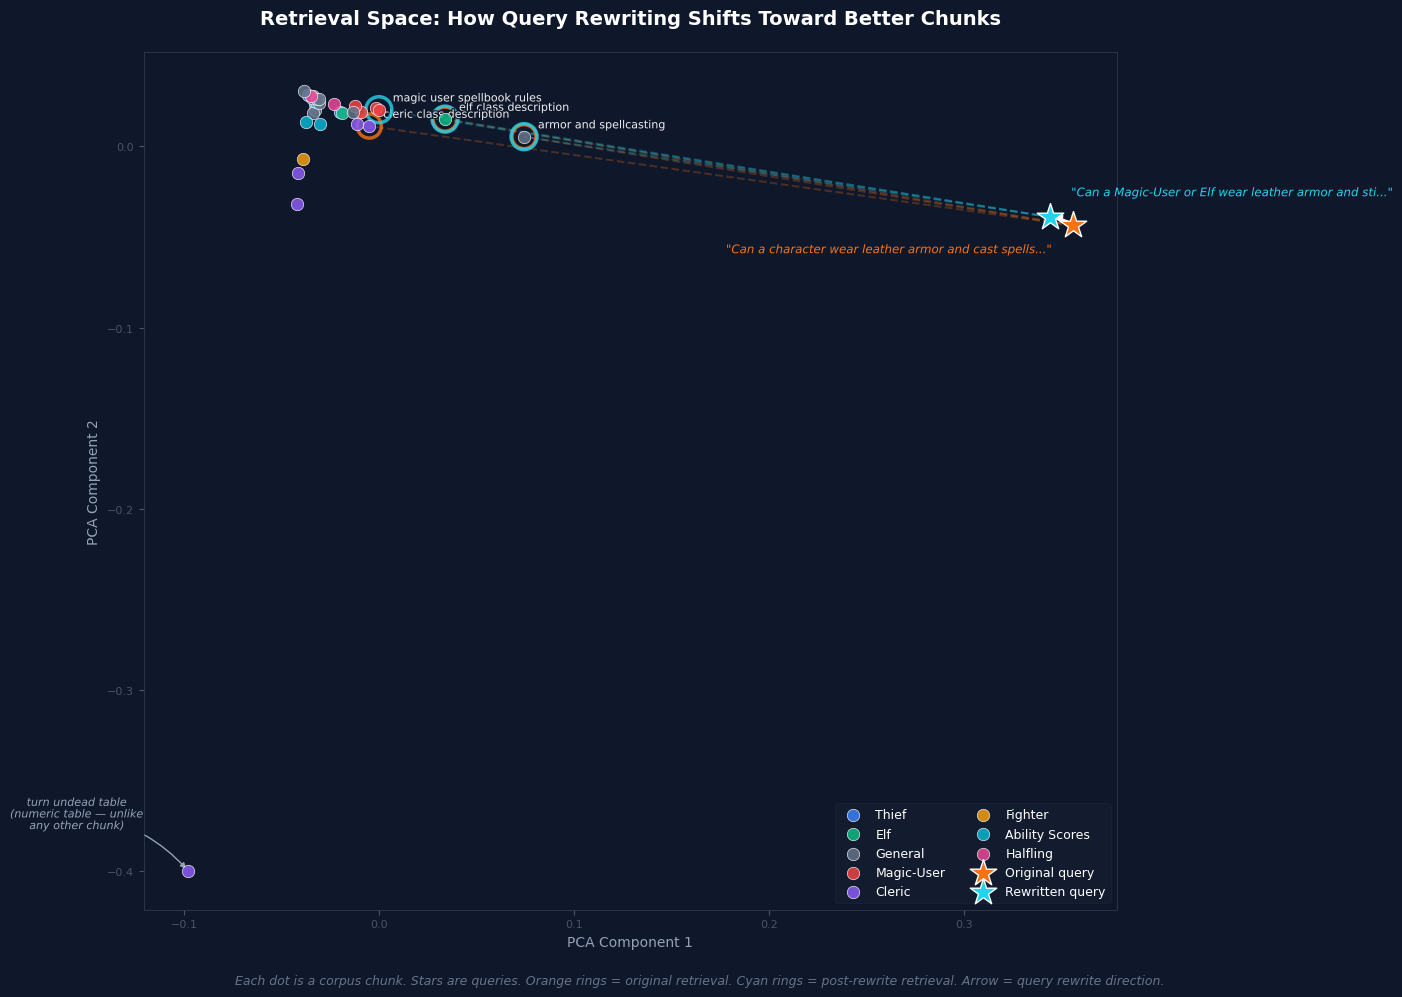

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from utils.retriever import _tokenize, _tfidf_vector

# --- Build the full TF-IDF matrix (chunks + both queries) ---
idf = collection._idf
all_tokens = [_tokenize(t) for t in collection._texts]
chunk_ids = [c["id"] for c in collection.chunks]

# Short labels for display (e.g. "elf_hit_die" -> "elf hit die")
short_labels = [cid.replace("_", " ") for cid in chunk_ids]

# Queries from the rewrite demo above
original_query = fail_q["question"]
rewritten_query = rewrite["rewritten_query"]

# Build vectors for all chunks + both queries
vocab = sorted(idf.keys())
vocab_idx = {t: i for i, t in enumerate(vocab)}
n_vocab = len(vocab)

def to_dense(tokens):
    vec = _tfidf_vector(tokens, idf)
    dense = np.zeros(n_vocab)
    for t, v in vec.items():
        if t in vocab_idx:
            dense[vocab_idx[t]] = v
    return dense

chunk_matrix = np.array([to_dense(tl) for tl in all_tokens])
q1_vec = to_dense(_tokenize(original_query))
q2_vec = to_dense(_tokenize(rewritten_query))

# Stack everything and do PCA via SVD (no sklearn needed)
all_vecs = np.vstack([chunk_matrix, q1_vec[None, :], q2_vec[None, :]])
centered = all_vecs - all_vecs.mean(axis=0)
U, S, Vt = np.linalg.svd(centered, full_matrices=False)
projected = U[:, :2] * S[:2]

chunk_pts = projected[:-2]
q1_pt = projected[-2]
q2_pt = projected[-1]

# --- Identify retrieved chunks for each query ---
r1 = collection.query(query_texts=[original_query], n_results=3)
r2 = collection.query(query_texts=[rewritten_query], n_results=3)

retrieved_1_idx = [collection._texts.index(d) for d in r1["documents"][0]]
retrieved_2_idx = [collection._texts.index(d) for d in r2["documents"][0]]

# --- Find the outlier chunk (furthest from centroid) ---
centroid = chunk_pts.mean(axis=0)
dists_from_center = np.linalg.norm(chunk_pts - centroid, axis=1)
outlier_idx = int(np.argmax(dists_from_center))

# --- Color chunks by topic cluster (based on source_section keywords) ---
topic_colors = {}
color_palette = ["#64748b", "#3b82f6", "#10b981", "#f59e0b",
                 "#ef4444", "#8b5cf6", "#ec4899", "#06b6d4"]
for i, chunk in enumerate(collection.chunks):
    section = chunk.get("source_section", "")
    if "thief" in section.lower():
        topic_colors[i] = (color_palette[1], "Thief")
    elif "elf" in section.lower():
        topic_colors[i] = (color_palette[2], "Elf")
    elif "magic-user" in section.lower() or "magic user" in section.lower():
        topic_colors[i] = (color_palette[4], "Magic-User")
    elif "cleric" in section.lower():
        topic_colors[i] = (color_palette[5], "Cleric")
    elif "fighter" in section.lower():
        topic_colors[i] = (color_palette[3], "Fighter")
    elif "halfling" in section.lower():
        topic_colors[i] = (color_palette[6], "Halfling")
    elif "ability" in section.lower() or "strength" in section.lower() or "dexterity" in section.lower():
        topic_colors[i] = (color_palette[7], "Ability Scores")
    else:
        topic_colors[i] = (color_palette[0], "General")

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 10), facecolor="#0f172a")
ax.set_facecolor("#0f172a")

# Draw faint connection lines from queries to their retrieved chunks
for idx in retrieved_1_idx:
    ax.plot([q1_pt[0], chunk_pts[idx, 0]], [q1_pt[1], chunk_pts[idx, 1]],
            color="#f97316", alpha=0.25, linewidth=1.5, linestyle="--", zorder=1)
for idx in retrieved_2_idx:
    ax.plot([q2_pt[0], chunk_pts[idx, 0]], [q2_pt[1], chunk_pts[idx, 1]],
            color="#22d3ee", alpha=0.25, linewidth=1.5, linestyle="--", zorder=1)

# Draw arrow from original query to rewritten query
ax.annotate("", xy=(q2_pt[0], q2_pt[1]), xytext=(q1_pt[0], q1_pt[1]),
            arrowprops=dict(arrowstyle="-|>", color="#ffffff", lw=2,
                            connectionstyle="arc3,rad=0.15"),
            zorder=5)

# Plot all chunks
plotted_topics = set()
for i in range(len(chunk_pts)):
    color, topic = topic_colors[i]
    label = topic if topic not in plotted_topics else None
    plotted_topics.add(topic)

    # Highlight retrieved chunks with glowing rings
    if i in retrieved_1_idx:
        ax.scatter(chunk_pts[i, 0], chunk_pts[i, 1], s=300, facecolors="none",
                   edgecolors="#f97316", linewidths=2.5, alpha=0.8, zorder=3)
    if i in retrieved_2_idx:
        ax.scatter(chunk_pts[i, 0], chunk_pts[i, 1], s=350, facecolors="none",
                   edgecolors="#22d3ee", linewidths=2.5, alpha=0.8, zorder=3)

    ax.scatter(chunk_pts[i, 0], chunk_pts[i, 1], s=80, c=color,
               alpha=0.85, zorder=4, edgecolors="white", linewidths=0.5,
               label=label)

    # Label retrieved chunks
    if i in retrieved_1_idx or i in retrieved_2_idx:
        ax.annotate(short_labels[i],
                    (chunk_pts[i, 0], chunk_pts[i, 1]),
                    textcoords="offset points", xytext=(10, 6),
                    fontsize=8, color="white", alpha=0.9,
                    path_effects=[pe.withStroke(linewidth=2, foreground="#0f172a")])

# Annotate the outlier with a callout
ax.annotate(
    f"{short_labels[outlier_idx]}\n(numeric table, unlike\nany other chunk)",
    (chunk_pts[outlier_idx, 0], chunk_pts[outlier_idx, 1]),
    textcoords="offset points", xytext=(-80, 30),
    fontsize=8, color="#94a3b8", fontstyle="italic",
    ha="center",
    path_effects=[pe.withStroke(linewidth=2, foreground="#0f172a")],
    arrowprops=dict(arrowstyle="-|>", color="#94a3b8", lw=1,
                    connectionstyle="arc3,rad=-0.2")
)

# Plot queries as stars
ax.scatter(*q1_pt, s=400, c="#f97316", marker="*", zorder=6,
           edgecolors="white", linewidths=1.0, label="Original query")
ax.scatter(*q2_pt, s=400, c="#22d3ee", marker="*", zorder=6,
           edgecolors="white", linewidths=1.0, label="Rewritten query")

# Query text annotations
ax.annotate(f'"{original_query[:50]}..."',
            (q1_pt[0], q1_pt[1]), textcoords="offset points", xytext=(-15, -20),
            fontsize=8.5, color="#f97316", fontstyle="italic",
            path_effects=[pe.withStroke(linewidth=2, foreground="#0f172a")],
            ha="right")
ax.annotate(f'"{rewritten_query[:50]}..."',
            (q2_pt[0], q2_pt[1]), textcoords="offset points", xytext=(15, 15),
            fontsize=8.5, color="#22d3ee", fontstyle="italic",
            path_effects=[pe.withStroke(linewidth=2, foreground="#0f172a")],
            ha="left")

# Legend: bottom right, away from the main cluster
legend = ax.legend(loc="lower right", fontsize=9, framealpha=0.3,
                   facecolor="#1e293b", edgecolor="#334155",
                   labelcolor="white", ncol=2)
legend.get_frame().set_linewidth(0.5)

ax.set_title("Retrieval Space: How Query Rewriting Shifts Toward Better Chunks",
             fontsize=14, fontweight="bold", color="white", pad=20)
ax.set_xlabel("PCA Component 1", fontsize=10, color="#94a3b8")
ax.set_ylabel("PCA Component 2", fontsize=10, color="#94a3b8")
ax.tick_params(colors="#475569", labelsize=8)
for spine in ax.spines.values():
    spine.set_color("#334155")
    spine.set_linewidth(0.5)

fig.text(0.5, 0.01,
         "Each dot is a corpus chunk. Stars are queries. "
         "Orange rings = original retrieval. Cyan rings = post-rewrite retrieval. "
         "Arrow = query rewrite direction.",
         ha="center", fontsize=9, color="#64748b", style="italic")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

This is what the agent loop makes possible. A passive pipeline would have taken whatever the orange rings returned and answered from it. The agent inspected that result, decided it was not good enough, rewrote the query, and retrieved again.

The plot makes the improvement visible: the rewritten query lands in a different part of the space, pulling in chunks that are genuinely relevant to the question. The model did not change. The corpus did not change. The query changed, because the architecture gave the model the opportunity to change it.

Notice the isolated point far from the main cluster. That is the **Turn Undead table**, a chunk made almost entirely of numbers, dashes, and formatting rather than natural language. TF-IDF sees it as having almost nothing in common with the other chunks, so it lands far away. This is a real property of the data, not a bug: structured tables and prose descriptions live in very different parts of the vector space, which is one reason table-lookup questions are hard for keyword-based retrieval.

> **Note:** This is a 2D projection of a high-dimensional space, so distances in the plot are approximate. The relative positions and cluster structure are meaningful; exact pixel distances are not.

### Explore the Retrieval Space

The static plot above shows one query and its rewrite. But the evaluation set has 10 questions, each landing in a different part of the space. Some will cluster near the right chunks on the first try. Others will not.

The interactive version below lets you explore this directly:

- **Hover** over any dot to see the chunk ID, topic, and full source section
- **Use the dropdown** at the top of the chart to switch between all 10 evaluation questions
- **Zoom and pan** to inspect dense clusters up close

This is the same PCA projection as above. The difference is that you can now see the full retrieval landscape across every question the pipeline needs to answer.

In [67]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "-q"])

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe'
import numpy as np
from utils.retriever import _tokenize, _tfidf_vector

# --- Project all 10 eval queries into the same PCA space ---
mean_vec = all_vecs.mean(axis=0)
basis = Vt[:2, :]

def project_query(q_vec):
    return (q_vec - mean_vec) @ basis.T

# Build data for each question
query_data = []
for r in results:
    q_vec = to_dense(_tokenize(r["question"]))
    q_pt = project_query(q_vec)

    ret = collection.query(query_texts=[r["question"]], n_results=3)
    ret_idx = [collection._texts.index(d) for d in ret["documents"][0]]
    ret_dists = ret["distances"][0]

    query_data.append({
        "id": r["id"],
        "question": r["question"],
        "classification": r["classification"],
        "q_pt": q_pt,
        "ret_idx": ret_idx,
        "ret_dists": ret_dists
    })

# --- Build one figure with all questions as frames + dropdown ---
# Chunk hover info
hover_texts = []
for i, chunk in enumerate(collection.chunks):
    _, topic = topic_colors[i]
    hover_texts.append(
        f"<b>{short_labels[i]}</b><br>"
        f"Topic: {topic}<br>"
        f"Source: {chunk.get('source_section', '')}<br>"
        f"Text: {chunk['text'][:150]}..."
    )

# We'll build each question as a set of traces toggled by a dropdown
fig = go.Figure()

# Background chunks (always visible)
fig.add_trace(go.Scatter(
    x=chunk_pts[:, 0].tolist(), y=chunk_pts[:, 1].tolist(),
    mode="markers",
    marker=dict(
        size=10,
        color=[topic_colors[i][0] for i in range(len(chunk_pts))],
        opacity=0.5,
        line=dict(width=0.5, color="white")
    ),
    text=hover_texts,
    hoverinfo="text",
    name="Corpus chunks"
))

# For each question, add traces (initially invisible except first)
traces_per_question = 4  # retrieved highlights, connection lines (as one trace), query star, label
first_extra_trace = 1  # index after the background trace

for qi, qd in enumerate(query_data):
    visible = (qi == 0)
    ret_idx = qd["ret_idx"]
    q_pt = qd["q_pt"]
    status = "PASS" if qd["classification"] == "pass" else "FAIL"

    # Trace 1: Retrieved chunk highlights with rings
    fig.add_trace(go.Scatter(
        x=chunk_pts[ret_idx, 0].tolist(),
        y=chunk_pts[ret_idx, 1].tolist(),
        mode="markers+text",
        marker=dict(
            size=20,
            color=[topic_colors[i][0] for i in ret_idx],
            opacity=0.95,
            line=dict(width=3, color="#f97316")
        ),
        text=[short_labels[i] for i in ret_idx],
        textposition="top center",
        textfont=dict(size=9, color="white"),
        customdata=[
            f"{hover_texts[i]}<br><b>Distance: {qd['ret_dists'][j]:.4f}</b>"
            for j, i in enumerate(ret_idx)
        ],
        hovertemplate="%{customdata}<extra>Retrieved</extra>",
        name="Retrieved chunks",
        visible=visible,
        showlegend=(qi == 0)
    ))

    # Trace 2: Connection lines from query to retrieved chunks
    line_x, line_y = [], []
    for idx in ret_idx:
        line_x.extend([q_pt[0], chunk_pts[idx, 0], None])
        line_y.extend([q_pt[1], chunk_pts[idx, 1], None])

    fig.add_trace(go.Scatter(
        x=line_x, y=line_y,
        mode="lines",
        line=dict(color="#f97316", width=1.5, dash="dash"),
        opacity=0.3,
        showlegend=False,
        hoverinfo="skip",
        visible=visible
    ))

    # Trace 3: Query star
    fig.add_trace(go.Scatter(
        x=[q_pt[0]], y=[q_pt[1]],
        mode="markers",
        marker=dict(size=20, color="#f97316", symbol="star",
                    line=dict(width=2, color="white")),
        name="Query",
        hovertemplate=(
            f"<b>{qd['id']}</b><br>"
            f"{qd['question']}<br>"
            f"Passive result: {status}"
            "<extra>Query</extra>"
        ),
        visible=visible,
        showlegend=(qi == 0)
    ))

    # Trace 4: Query text annotation (as invisible scatter with text)
    fig.add_trace(go.Scatter(
        x=[q_pt[0]], y=[q_pt[1]],
        mode="text",
        text=[f'  "{qd["question"][:45]}..."'],
        textposition="bottom right",
        textfont=dict(size=10, color="#f97316"),
        showlegend=False,
        hoverinfo="skip",
        visible=visible
    ))

# Build dropdown buttons
buttons = []
for qi, qd in enumerate(query_data):
    status = "PASS" if qd["classification"] == "pass" else "FAIL"
    visibility = [True]  # background chunks always visible
    for qj in range(len(query_data)):
        vis = (qj == qi)
        visibility.extend([vis] * traces_per_question)

    buttons.append(dict(
        label=f"{qd['id']} [{status}]: {qd['question'][:45]}",
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"Retrieval Space: {qd['id']} : {qd['question'][:55]}"}
        ]
    ))

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.0, xanchor="left",
        y=1.15, yanchor="top",
        bgcolor="#1e293b",
        bordercolor="#334155",
        font=dict(color="white", size=11)
    )],
    template="plotly_dark",
    paper_bgcolor="#0f172a",
    plot_bgcolor="#0f172a",
    title=dict(
        text=f"Retrieval Space: {query_data[0]['id']} : {query_data[0]['question'][:55]}",
        font=dict(size=14, color="white")
    ),
    xaxis=dict(title="PCA Component 1", gridcolor="#1e293b", zerolinecolor="#334155"),
    yaxis=dict(title="PCA Component 2", gridcolor="#1e293b", zerolinecolor="#334155"),
    legend=dict(
        font=dict(size=10, color="white"),
        bgcolor="rgba(30,41,59,0.7)",
        bordercolor="#334155",
        x=1.0, xanchor="right", y=0.0, yanchor="bottom"
    ),
    width=950, height=700,
    margin=dict(t=80, b=40, l=60, r=40)
)

# Add outlier annotation (always visible)
fig.add_annotation(
    x=chunk_pts[outlier_idx, 0], y=chunk_pts[outlier_idx, 1],
    text=f"{short_labels[outlier_idx]}<br><i>(numeric table)</i>",
    showarrow=True, arrowhead=2, arrowcolor="#94a3b8",
    font=dict(size=10, color="#94a3b8"),
    bgcolor="rgba(15,23,42,0.8)", bordercolor="#334155"
)

fig.show()

### Corpus Coverage Heatmap

The scatter plot shows where individual queries land relative to the chunks. The heatmap below shows the full picture at once: **every question against every chunk**.

Each row is one of the 10 evaluation questions. Each column is one of the 30 corpus chunks, grouped by topic. The color of each cell represents how similar that chunk is to the question; brighter means closer.

Look for:

- **Bright columns**: chunks that are useful to many questions (general-purpose context)
- **Bright rows**: questions that have strong matches across the corpus (easy for retrieval)
- **Dark rows**: questions with no strong match anywhere (the ones the passive pipeline gets wrong)
- **Isolated bright cells**: questions that depend on exactly one chunk to get right (fragile retrieval)

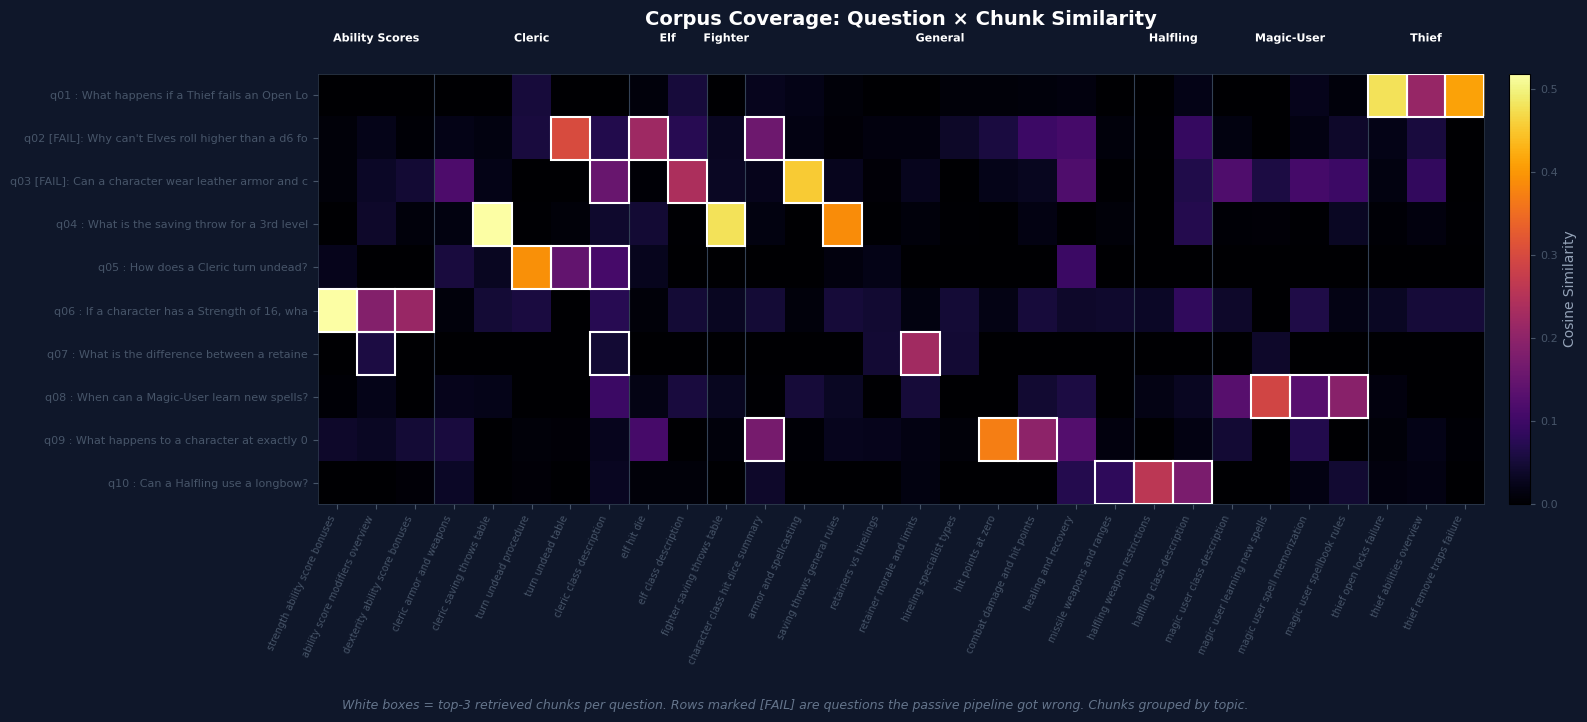

In [68]:
# --- Build similarity matrix: 10 questions x 30 chunks ---
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from utils.retriever import _tokenize, _tfidf_vector

# Compute cosine similarity between each question and each chunk
def cosine_sim(a, b):
    dot = np.dot(a, b)
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return dot / (na * nb)

# Dense vectors for all questions
question_vecs = [to_dense(_tokenize(r["question"])) for r in results]
chunk_vecs = [to_dense(tl) for tl in all_tokens]

sim_matrix = np.zeros((len(results), len(collection.chunks)))
for qi, qv in enumerate(question_vecs):
    for ci, cv in enumerate(chunk_vecs):
        sim_matrix[qi, ci] = cosine_sim(qv, cv)

# Sort chunks by topic for cleaner visual grouping
topic_order = []
topic_group_labels = []
seen_topics = []
for i, chunk in enumerate(collection.chunks):
    _, topic = topic_colors[i]
    topic_order.append((topic, i))

topic_order.sort(key=lambda x: x[0])
sorted_chunk_idx = [t[1] for t in topic_order]
sorted_chunk_topics = [t[0] for t in topic_order]
sorted_chunk_labels = [short_labels[i] for i in sorted_chunk_idx]

sim_sorted = sim_matrix[:, sorted_chunk_idx]

# Question labels
q_labels = [f"{r['id']} {'[FAIL]' if r['classification'] != 'pass' else ''}: {r['question'][:40]}"
            for r in results]

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 7), facecolor="#0f172a")
ax.set_facecolor("#0f172a")

# Use a perceptual colormap: dark = low similarity, bright = high
im = ax.imshow(sim_sorted, aspect="auto", cmap="inferno",
               interpolation="nearest", vmin=0, vmax=sim_sorted.max())

# Mark the top-3 retrieved chunks per question with white boxes
for qi in range(len(results)):
    row = sim_sorted[qi]
    top3 = np.argsort(row)[-3:]
    for ci in top3:
        rect = plt.Rectangle((ci - 0.5, qi - 0.5), 1, 1,
                              linewidth=1.5, edgecolor="white",
                              facecolor="none", zorder=3)
        ax.add_patch(rect)

# Axis labels
ax.set_xticks(range(len(sorted_chunk_labels)))
ax.set_xticklabels(sorted_chunk_labels, rotation=65, ha="right",
                   fontsize=7, color="#94a3b8")
ax.set_yticks(range(len(q_labels)))
ax.set_yticklabels(q_labels, fontsize=8, color="#94a3b8")

# Topic group separators and labels along the top
prev_topic = None
group_starts = []
for ci, topic in enumerate(sorted_chunk_topics):
    if topic != prev_topic:
        if prev_topic is not None:
            ax.axvline(x=ci - 0.5, color="#334155", linewidth=0.8, linestyle="-")
        group_starts.append((ci, topic))
        prev_topic = topic

# Topic labels along the top
for gi, (start, topic) in enumerate(group_starts):
    end = group_starts[gi + 1][0] if gi + 1 < len(group_starts) else len(sorted_chunk_labels)
    mid = (start + end - 1) / 2
    ax.text(mid, -1.2, topic, ha="center", va="bottom", fontsize=8,
            color="white", fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2, foreground="#0f172a")])



# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("Cosine Similarity", color="#94a3b8", fontsize=10)
cbar.ax.tick_params(colors="#475569", labelsize=8)

ax.set_title("Corpus Coverage: Question \u00d7 Chunk Similarity",
             fontsize=14, fontweight="bold", color="white", pad=35)

# Tick styling
ax.tick_params(axis="both", colors="#475569")
for spine in ax.spines.values():
    spine.set_color("#334155")
    spine.set_linewidth(0.5)

fig.text(0.5, -0.02,
         "White boxes = top-3 retrieved chunks per question. "
         "Rows marked [FAIL] are questions the passive pipeline got wrong. "
         "Chunks grouped by topic.",
         ha="center", fontsize=9, color="#64748b", style="italic")

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

The heatmap reveals the retrieval landscape in a way the scatter plot cannot. A few things to notice:

- **The failing questions** (marked with red dots) tend to have dimmer rows; their best matches are weaker than those of passing questions. The retriever is not broken; it simply has less to work with for these questions.
- **Topic clustering is visible in the columns.** Chunks from the same section light up together, confirming that the retriever groups related content. But a question that needs facts from *two different sections* will only match one cluster well.
- **The white boxes show what the retriever actually picks.** Sometimes the top-3 are all from the same topic cluster. Sometimes they scatter across the heatmap. That pattern tells you whether the retriever is casting a wide net or a narrow one.

This is the information the passive pipeline never inspects. It takes whatever the top-3 are and answers. The agent loop gives the model the chance to look at this landscape and decide whether the retrieval was good enough.

## 2.5 The Agent Loop

Now we have two capabilities the passive pipeline lacked:

1. **Evaluate** whether retrieval was sufficient
2. **Rewrite** the query and try again when it was not

The agent loop connects these into a decision cycle:

```
   Question arrives
        |
        v
   RETRIEVE chunks
        |
        v
   EVALUATE: sufficient?
       / \
     yes   no
      |     |
      v     v
   ANSWER  REWRITE query
      |     |
      v     v
   done   RETRIEVE again
            |
            v
         EVALUATE: sufficient?
            / \
          yes   no (max retries)
           |     |
           v     v
        ANSWER  ABSTAIN
```

The loop has a maximum number of iterations. If the agent cannot find sufficient context after all retries, it says so. That is better than a confident wrong answer.

The cell below implements this loop. Read the code before running it.

In [69]:
ANSWER_PROMPT = """You are a rules assistant for Basic Fantasy RPG.
Use only the context below to answer the question.
If the context does not contain enough information, say so clearly.

Context:
{context}

Question: {question}"""


def agent_rag(question, collection, model_client, model_id,
              n_results=3, max_retries=2, verbose=True):
    """
    The agent loop: retrieve, evaluate, decide.

    Unlike passive_rag, this function can:
    - Judge whether retrieval was sufficient before answering
    - Rewrite the query and retry when retrieval is weak
    - Abstain when it cannot find sufficient context
    """
    trace = []  # Record every step for inspection
    current_query = question

    for attempt in range(1, max_retries + 2):  # +2 because range is exclusive and we start at 1
        # STEP 1: Retrieve
        retrieved = collection.query(
            query_texts=[current_query],
            n_results=n_results,
            include=["documents", "distances"]
        )
        chunks = retrieved["documents"][0]
        distances = retrieved["distances"][0]

        step = {
            "attempt": attempt,
            "query": current_query,
            "distances": distances
        }

        if verbose:
            print(f"\n--- Attempt {attempt} ---")
            print(f"Query: {current_query}")
            print(f"Distances: {[f'{d:.4f}' for d in distances]}")

        # STEP 2: Evaluate
        eval_result = evaluate_retrieval(question, chunks, model_client, model_id)
        step["eval"] = eval_result

        if verbose:
            print(f"Verdict: {eval_result['verdict']}")
            print(f"Reason: {eval_result.get('reason', '')}")

        # STEP 3: Decide
        if eval_result["verdict"] == "sufficient":
            # Answer
            context = "\n\n".join(chunks)
            prompt = ANSWER_PROMPT.format(context=context, question=question)
            response = model_client.chat.completions.create(
                model=model_id,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0
            )
            answer = response.choices[0].message.content
            step["action"] = "answer"
            step["answer"] = answer
            trace.append(step)

            if verbose:
                print(f"Action: ANSWER")

            return {
                "answer": answer,
                "status": "answered",
                "attempts": attempt,
                "trace": trace
            }

        elif attempt <= max_retries:
            # Rewrite and retry
            rewrite = rewrite_query(question, eval_result, model_client, model_id)
            current_query = rewrite["rewritten_query"]
            step["action"] = "rewrite"
            step["rewrite"] = rewrite
            trace.append(step)

            if verbose:
                print(f"Action: REWRITE -> {current_query}")

        else:
            # Exhausted retries, answer with best available context
            context = "\n\n".join(chunks)
            prompt = ANSWER_PROMPT.format(context=context, question=question)
            response = model_client.chat.completions.create(
                model=model_id,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0
            )
            answer = response.choices[0].message.content
            step["action"] = "answer_with_caveat"
            step["answer"] = answer
            trace.append(step)

            if verbose:
                print(f"Action: ANSWER (best effort after {attempt} attempts)")

            return {
                "answer": answer,
                "status": "best_effort",
                "attempts": attempt,
                "trace": trace
            }


print("Agent loop defined.")

Agent loop defined.


The loop’s final branch (the max-retries path) does not truly abstain. It answers with the best available context and marks the result as best-effort rather than refusing to respond. That is a deliberate choice. A confident refusal is only appropriate when you are certain the corpus does not contain the answer, and the agent cannot be certain of that after a fixed number of retries. The retrieval may have failed because the query was never phrased correctly, not because the answer is absent. Best-effort with explicit uncertainty is more useful than silence.

A production system might add a third path: an out-of-scope classifier that runs before retrieval to catch questions the corpus provably cannot answer. That classifier would enable true abstention for questions outside the domain, without relying on the retry loop to discover the gap. The agent loop as built here handles the middle case (questions that are in scope but hard to retrieve for) and leaves the out-of-scope detection as a separate, upstream concern.

## 2.6 Testing the Agent Loop

Run the agent loop on each of the failing questions. Compare the agent's answers to the expected answers.

Watch the trace. The important thing is not just whether the final answer is correct. It is *how the agent got there*: how many retrieval attempts it made, what queries it rewrote, and what decisions it made along the way.

In [70]:
agent_results = []

for f_ in failures:
    print("=" * 70)
    print(f"QUESTION: {f_['question']}")
    print(f"EXPECTED: {f_['expected']}")
    print()

    result = agent_rag(
        question=f_["question"],
        collection=collection,
        model_client=client,
        model_id=config.MODEL_ID,
        max_retries=2,
        verbose=True
    )

    print(f"\nAGENT ANSWER: {result['answer'][:300]}")
    print(f"STATUS: {result['status']} (after {result['attempts']} attempt(s))")
    print()

    agent_results.append({
        "id": f_["id"],
        "question": f_["question"],
        "expected": f_["expected"],
        "agent_answer": result["answer"],
        "status": result["status"],
        "attempts": result["attempts"],
        "trace": result["trace"]
    })

QUESTION: Why can't Elves roll higher than a d6 for hit points?
EXPECTED: Elves use a d6 for hit points because that is the hit die assigned to the Elf combination class in Basic Fantasy RPG.


--- Attempt 1 ---
Query: Why can't Elves roll higher than a d6 for hit points?
Distances: ['0.6974', '0.7787', '0.8401']
Verdict: sufficient
Reason: The chunks explain that Elves are a combination class incorporating Fighter and Magic-User abilities, and as such, they use the smaller hit die of the two component classes, which is a d6, the same as Magic-Users.
Action: ANSWER

AGENT ANSWER: Elves cannot roll higher than a d6 for hit points because they are a combination class, incorporating the abilities of both the Fighter and the Magic-User. In Basic Fantasy RPG, combination classes use the smaller hit die of the two component classes. Since Elves combine the Fighter and Magic-User c
STATUS: answered (after 1 attempt(s))

QUESTION: Can a character wear leather armor and cast spells?
EXPECTED: M

## 2.7 Scoring the Agent

Use the same model to classify whether the agent's answers are correct. This is the same evaluation method from the Escalation Lab, applied to the agent's output.

In [71]:
JUDGE_PROMPT = """You are an evaluation judge. Compare the EXPECTED answer to the ACTUAL answer.

The ACTUAL answer is correct if it conveys the same key facts as the EXPECTED answer,
even if the wording differs. Minor omissions of non-essential details are acceptable.

Respond with EXACTLY one JSON object:
{"classification": "pass" or "fail", "reason": "<one sentence>"}
"""


def judge_answer(question, expected, actual, model_client, model_id):
    """Judge whether the agent's answer matches the expected answer."""
    response = model_client.chat.completions.create(
        model=model_id,
        messages=[
            {"role": "system", "content": JUDGE_PROMPT},
            {"role": "user", "content": f"QUESTION: {question}\n\nEXPECTED: {expected}\n\nACTUAL: {actual}"}
        ],
        temperature=0.0
    )
    raw = response.choices[0].message.content.strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"classification": "error", "reason": "Could not parse judge response", "raw": raw}


print("Scoring agent results...\n")
print(f"{'ID':<6} {'Passive':<10} {'Agent':<10} {'Attempts':<10} {'Question'}")
print("-" * 80)

agent_passes = 0
for ar in agent_results:
    judgment = judge_answer(
        ar["question"], ar["expected"], ar["agent_answer"], client, config.MODEL_ID
    )
    ar["agent_classification"] = judgment["classification"]
    ar["judge_reason"] = judgment.get("reason", "")

    if judgment["classification"] == "pass":
        agent_passes += 1

    print(f"{ar['id']:<6} {'fail':<10} {judgment['classification']:<10} {ar['attempts']:<10} {ar['question'][:50]}")

print(f"\nAgent recovered {agent_passes} of {len(failures)} previously failing questions.")

Scoring agent results...

ID     Passive    Agent      Attempts   Question
--------------------------------------------------------------------------------
q02    fail       pass       1          Why can't Elves roll higher than a d6 for hit poin
q03    fail       pass       1          Can a character wear leather armor and cast spells

Agent recovered 2 of 2 previously failing questions.


## 2.8 Comparing Architectures

The table below shows the full picture: all 10 questions, passive vs. agent.

In [72]:
# Build the combined results
agent_lookup = {ar["id"]: ar for ar in agent_results}

print(f"{'ID':<6} {'Passive':<10} {'Agent':<10} {'Question'}")
print("=" * 80)

passive_total = sum(1 for r in results if r["classification"] == "pass")
agent_total = passive_total  # Start with the questions that already passed

for r in results:
    passive_result = r["classification"]
    if r["id"] in agent_lookup:
        agent_result = agent_lookup[r["id"]]["agent_classification"]
        if agent_result == "pass":
            agent_total += 1
    else:
        agent_result = "pass"  # Already passed in passive pipeline

    passive_display = "pass" if passive_result == "pass" else "FAIL"
    agent_display = "pass" if agent_result == "pass" else "FAIL"

    print(f"{r['id']:<6} {passive_display:<10} {agent_display:<10} {r['question'][:50]}")

print("=" * 80)
print(f"{'TOTAL':<6} {passive_total}/10{'':<5} {agent_total}/10")

ID     Passive    Agent      Question
q01    pass       pass       What happens if a Thief fails an Open Locks attemp
q02    FAIL       pass       Why can't Elves roll higher than a d6 for hit poin
q03    FAIL       pass       Can a character wear leather armor and cast spells
q04    pass       pass       What is the saving throw for a 3rd level Fighter a
q05    pass       pass       How does a Cleric turn undead?
q06    pass       pass       If a character has a Strength of 16, what bonus do
q07    pass       pass       What is the difference between a retainer and a hi
q08    pass       pass       When can a Magic-User learn new spells?
q09    pass       pass       What happens to a character at exactly 0 hit point
q10    pass       pass       Can a Halfling use a longbow?
TOTAL  8/10      10/10


The model did not change. The corpus did not change. The retriever did not change. The only difference is the control structure around them.

This is the argument for agentic RAG: the components were already capable. The passive architecture just never gave them the opportunity to recover from failure.

The agent trace recorded in Section 2.9 is not only a debugging tool. It is the provenance chain that makes RAG auditable. Every step records which query was issued, which chunks were retrieved, what the evaluator judged, and what decision was made. In regulated enterprise contexts, the ability to trace a generated answer back to a specific retrieval decision and a specific source chunk is a governance requirement, not a feature. A fine-tuned model bakes knowledge into its weights and provides no equivalent trail. The agent loop produces answers and the evidence for those answers in the same pass.

## 2.9 Inspecting the Agent Trace

The trace recorded every decision the agent made. This is critical for production systems: you need to know *why* the agent answered the way it did, not just *what* it answered.

Pick a question and walk through its trace.

In [73]:
# Inspect the trace for the first agent result
inspect = agent_results[0]

print(f"Question: {inspect['question']}")
print(f"Expected: {inspect['expected']}")
print(f"Status  : {inspect['status']}")
print()

for step in inspect["trace"]:
    print(f"--- Attempt {step['attempt']} ---")
    print(f"  Query    : {step['query']}")
    print(f"  Distances: {[f'{d:.4f}' for d in step['distances']]}")
    print(f"  Verdict  : {step['eval']['verdict']}")
    print(f"  Reason   : {step['eval'].get('reason', '')}")
    print(f"  Action   : {step['action']}")
    if step['action'] == 'rewrite':
        print(f"  Rewrite  : {step['rewrite']['rewritten_query']}")
        print(f"  Strategy : {step['rewrite']['strategy']}")
    elif 'answer' in step:
        print(f"  Answer   : {step['answer'][:200]}")
    print()

Question: Why can't Elves roll higher than a d6 for hit points?
Expected: Elves use a d6 for hit points because that is the hit die assigned to the Elf combination class in Basic Fantasy RPG.
Status  : answered

--- Attempt 1 ---
  Query    : Why can't Elves roll higher than a d6 for hit points?
  Distances: ['0.6974', '0.7787', '0.8401']
  Verdict  : sufficient
  Reason   : The chunks explain that Elves are a combination class incorporating Fighter and Magic-User abilities, and as such, they use the smaller hit die of the two component classes, which is a d6, the same as Magic-Users.
  Action   : answer
  Answer   : Elves cannot roll higher than a d6 for hit points because they are a combination class, incorporating the abilities of both the Fighter and the Magic-User. In Basic Fantasy RPG, combination classes us



---

## Key Takeaways

1. **The passive pipeline's failures were architectural, not model failures.** The same model that produced wrong answers could detect bad retrieval and recover from it when given the opportunity.

2. **The agent loop adds three capabilities:** evaluate retrieval quality, rewrite queries, and decide when to abstain. None of these require a different model or different data.

3. **The trace is the audit trail.** Every decision is recorded. In production, this is how you debug, monitor, and improve the system.

4. **Complexity was added only where evidence justified it.** The passive pipeline worked for 8 of 10 questions. The agent loop was built specifically to address the 2 it could not handle.

---

> **FIELD TAKEAWAY**
>
> An agent loop is not a better model. It is a better control structure. The model evaluates its own retrieval, rewrites its own queries, and decides when to answer or abstain. The components stay the same. The architecture changes. That is the difference between passive and agentic RAG.